# ALR Daily: Autoregressive logistic model of DWTs

## 1. Loading the DWT model

In [1]:
from bluemath_tk.core.io import load_model

In [2]:
dwt_model = load_model("outputs/dwt_model.pkl")

In [3]:
dwt_kma_bmus_df = dwt_model.kma_bmus.copy()
dwt_kma_bmus_df.index.name = "time"
dwt_kma_bmus_df.columns = ["bmus"]
dwt_kma_bmus_ds = dwt_kma_bmus_df.to_xarray()
dwt_kma_bmus_ds

<xarray.Dataset> Size: 206kB
Dimensions:  (time: 17167)
Coordinates:
  * time     (time) datetime64[ns] 137kB 1979-01-01 1979-01-02 ... 2025-12-31
Data variables:
    bmus     (time) int32 69kB 13 6 6 6 6 15 4 2 6 ... 18 18 18 17 19 7 10 23 25

## 2. Covariates: PCs of the AWT

In [4]:
awt = load_model("outputs/awt_model.pkl")

In [5]:
covariates_ds = (
    awt.steps.get("pca")
    .pcs.resample(time="1D")
    .pad()
    .rename({"n_component": "n_covariates", "PCs": "cov_norm"})
    .drop(["stds", "kma_bmus"])
)
covariates_ds = (covariates_ds - covariates_ds.mean(dim="time")) / covariates_ds.std(
    dim="time"
)
covariates_ds["cov_names"] = (("n_covariates"), [f"PC{i}" for i in range(1, 4)])
covariates_ds

<xarray.Dataset> Size: 538kB
Dimensions:       (time: 16803, n_covariates: 3)
Coordinates:
  * time          (time) datetime64[ns] 134kB 1979-01-01 ... 2025-01-01
  * n_covariates  (n_covariates) int64 24B 0 1 2
Data variables:
    cov_norm      (time, n_covariates) float64 403kB 0.6601 0.02169 ... 0.8049
    cov_names     (n_covariates) <U3 36B 'PC1' 'PC2' 'PC3'

## 3. ALR Fit

In [6]:
from bluemath_tk.teslakit.alr import ALR_WRP

alr_terms = {
    "mk_order": 1,
    "constant": True,
    "long_term": False,
    "seasonality": (True, [2, 4]),
    "covariates": (
        True,
        covariates_ds.sel(time=dwt_kma_bmus_ds.time, method="nearest"),
    ),
}

alr_model = ALR_WRP(p_base="outputs/dwt_alr")
alr_model.SetFitData(
    cluster_size=dwt_model.num_clusters,
    xds_bmus_fit=dwt_kma_bmus_ds,
    d_terms_settings=alr_terms,
)
alr_model.FitModel(max_iter=2000)


Fitting autoregressive logistic model ...
Optimization done in 86.16 seconds



## 4. Model Coefficients

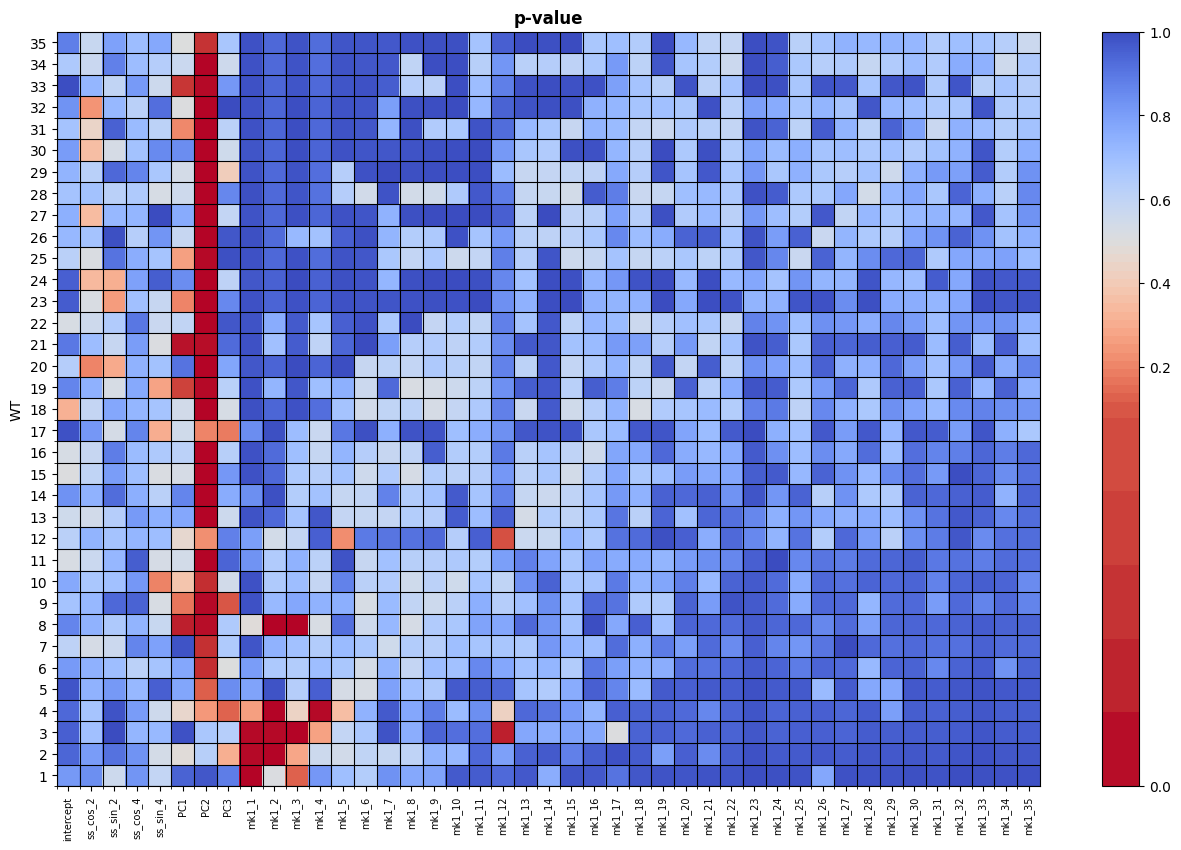

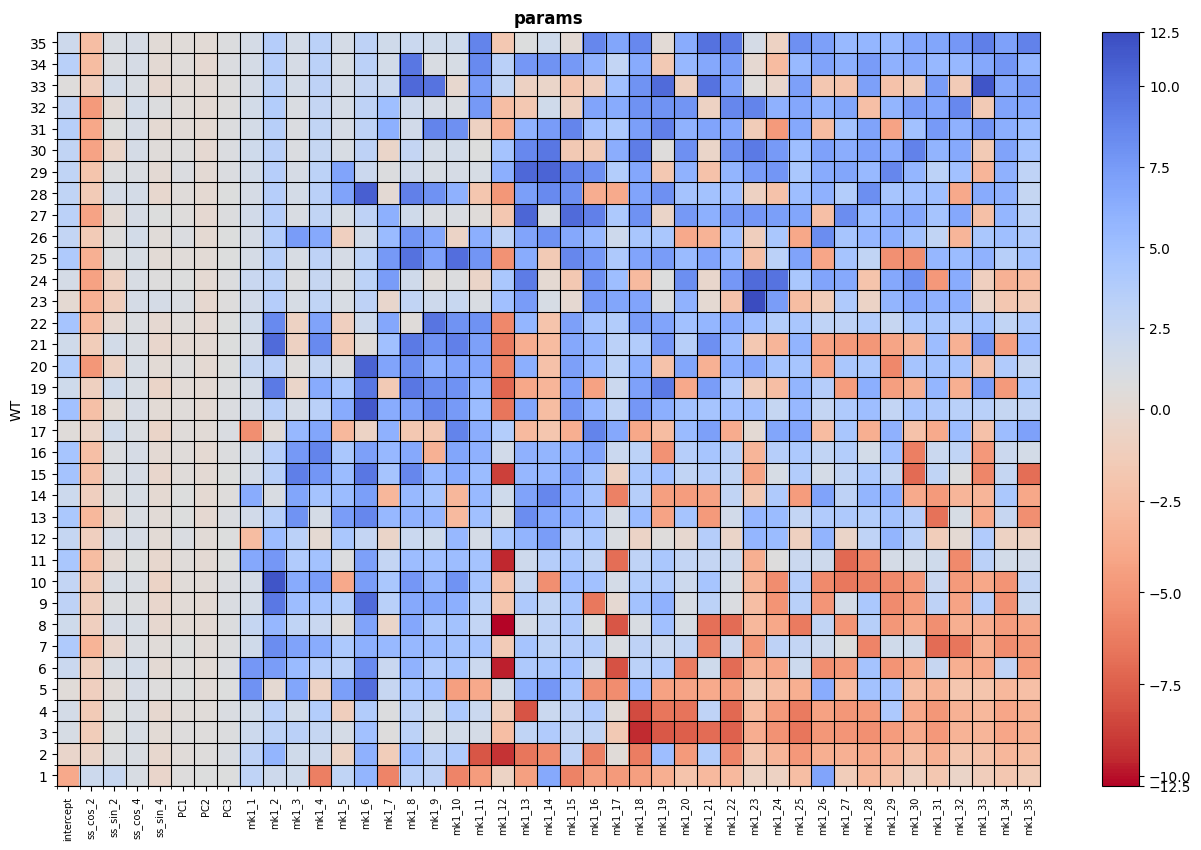

In [7]:
alr_model.Report_Fit()

## 5. Simulation

In [8]:
import xarray as xr

simulated_annual_PCs = (
    xr.open_dataset("outputs/simulated_PCs.nc").resample(time="1D").pad()
)
simulated_annual_PCs

<xarray.Dataset> Size: 89MB
Dimensions:     (time: 36891, n_sim: 100, n_covariates: 3)
Coordinates:
  * time        (time) datetime64[ns] 295kB 1999-01-01 1999-01-02 ... 2100-01-01
  * n_sim       (n_sim) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
Dimensions without coordinates: n_covariates
Data variables:
    cov_values  (n_sim, time, n_covariates) float64 89MB ...

In [9]:
# --------------------------------------
# Autoregressive Logistic Regression - simulate

# launch simulation
simulated_daily_bmus = alr_model.Simulate(
    num_sims=5,
    time_sim=simulated_annual_PCs.time.values,
    xds_covars_sim=simulated_annual_PCs,
)
simulated_daily_bmus

ALR model fit   : 1979-01-01 --- 2025-12-31
ALR model sim   : 1999-01-01 --- 2100-01-01

Launching 5 simulations...

Sim. Num. 005 (Covs. 005): 100%|██████████| 36890/36890 [00:20<00:00, 1760.53it/s]



<xarray.Dataset> Size: 2MB
Dimensions:      (time: 36891, n_sim: 5)
Coordinates:
  * time         (time) datetime64[ns] 295kB 1999-01-01 ... 2100-01-01
Dimensions without coordinates: n_sim
Data variables:
    evbmus_sims  (time, n_sim) int64 1MB 6 6 6 6 6 4 4 6 4 ... 7 7 18 7 7 9 7 5
    ofbmus_sims  (time, n_sim) bool 184kB False False False ... False False

In [10]:
simulated_daily_bmus.to_netcdf("outputs/xds_output.nc")

## 6. Validation

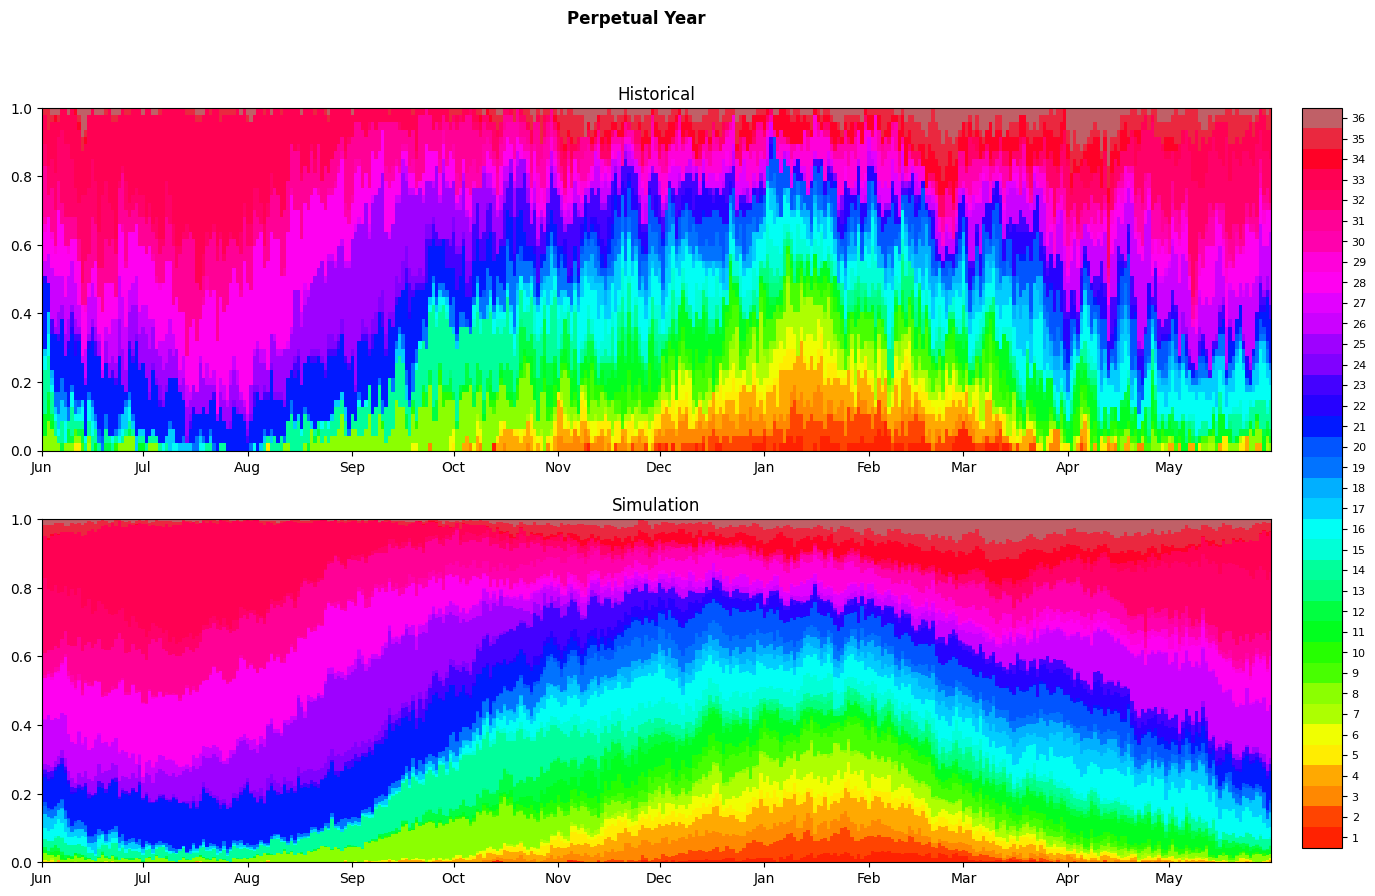

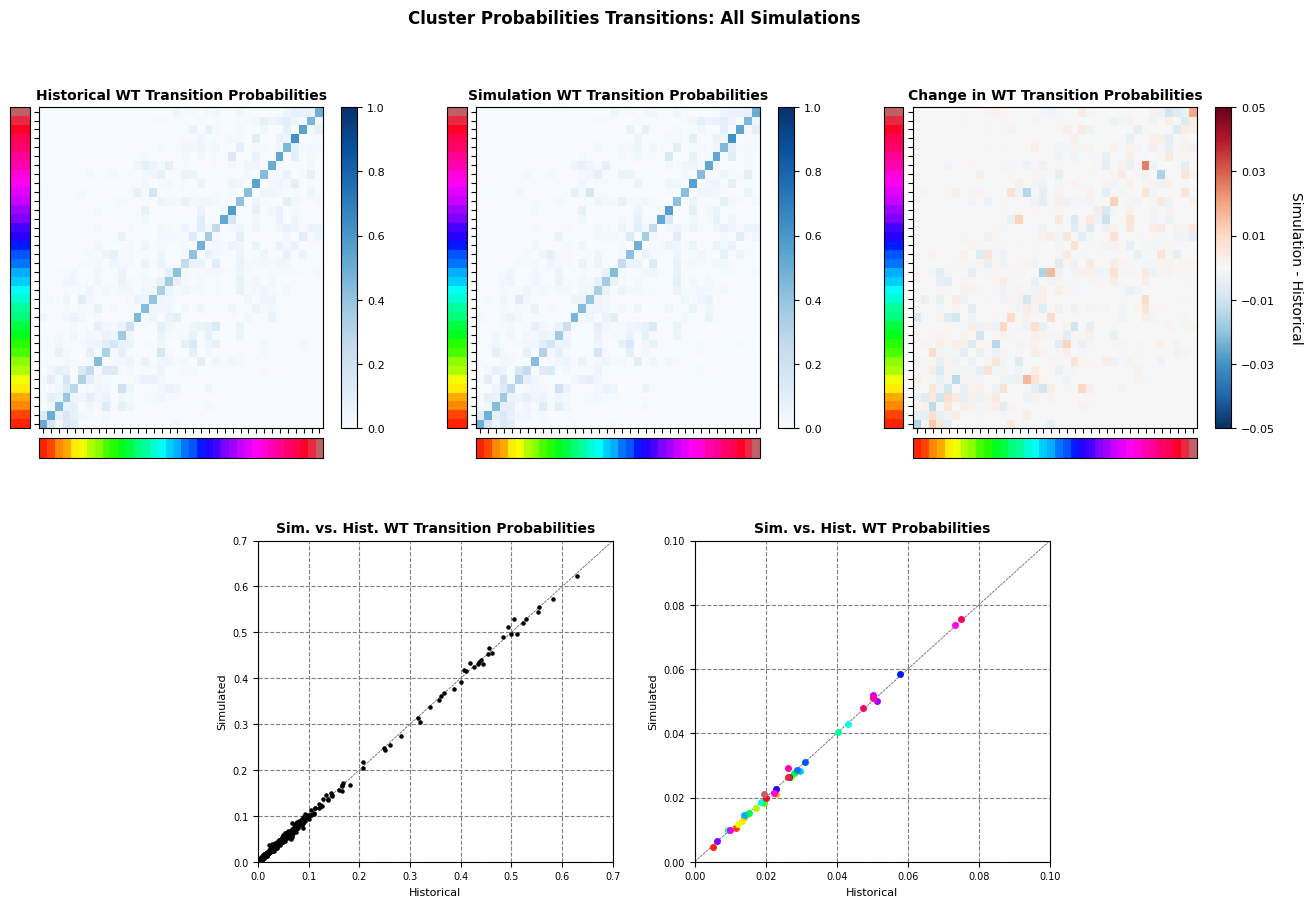

In [11]:
# show sim report

_fig = alr_model.Report_Sim(py_month_ini=6)

## 7. Additional validation plots

### 7.0 Setup

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.path import Path
from matplotlib.patches import PathPatch

# ---------- Historical series ----------
hist = dwt_kma_bmus_ds.bmus.values.astype(int)
hist_time = pd.to_datetime(dwt_kma_bmus_ds.time.values)

# ---------- Simulations ----------
sim_da = simulated_daily_bmus.evbmus_sims.transpose("n_sim", "time")
sims = sim_da.values.astype(int)                  # (n_sim, time)
sim_time = pd.to_datetime(sim_da.time.values)

K = dwt_model.num_clusters
n_hist = len(hist)
positions = np.arange(1, K + 1)

# ---------- Colors (BlueMath's own, if available) ----------
try:
    from bluemath_tk.core.plotting.colors import get_cluster_colors
    _c = np.asarray(get_cluster_colors(K), dtype=float)[:, :3]
    if _c.max() > 1:
        _c = _c / 255
    cmap = ListedColormap(_c)
except Exception:
    cmap = plt.get_cmap("turbo", K)
colors = cmap(np.arange(K))
norm = BoundaryNorm(np.arange(0.5, K + 1.5), K)

month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_names = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]

# ---------- Helpers ----------
def transition_counts(seq):
    C = np.zeros((K, K))
    np.add.at(C, (seq[:-1] - 1, seq[1:] - 1), 1)
    return C

def to_probs(C):
    rs = C.sum(axis=1, keepdims=True)
    return np.divide(C, rs, out=np.zeros_like(C), where=rs > 0)

def run_lengths(seq):
    """(DWT of each spell, length of each spell in days)."""
    change = np.flatnonzero(np.diff(seq)) + 1
    starts = np.r_[0, change]
    ends = np.r_[change, len(seq)]
    return seq[starts], ends - starts

# ---------- Simulated blocks with the same length as the historical record ----------
blocks = np.array([s[b * n_hist:(b + 1) * n_hist]
                   for s in sims for b in range(len(s) // n_hist)])
n_blocks = len(blocks)

P_hist = to_probs(transition_counts(hist))
P_blocks = np.array([to_probs(transition_counts(b)) for b in blocks])        # (n_blocks, K, K)
freq_hist = np.bincount(hist - 1, minlength=K) / n_hist
freq_blocks = np.array([np.bincount(b - 1, minlength=K) / len(b) for b in blocks])

def range_plot(ax, sim_vals, hist_vals):
    """Range (min-max) and value of each simulated block + historical, for the K DWTs."""
    lo, hi, mean = sim_vals.min(0), sim_vals.max(0), sim_vals.mean(0)
    ax.vlines(positions, lo, hi, colors=colors, lw=6, alpha=0.45)
    for k in range(K):
        ax.scatter(np.full(n_blocks, positions[k]), sim_vals[:, k], s=6, color="0.35", zorder=2)
    ax.scatter(positions, mean, marker="_", s=120, color="k", zorder=3, label="Simulated (mean)")
    ax.scatter(positions, hist_vals, marker="D", s=28, color="crimson", zorder=4, label="Historical")
    ax.set_xticks(positions)
    ax.set_xticklabels(positions, fontsize=8)
    ax.set_xlim(0.3, K + 0.7)
    ax.grid(axis="y", alpha=0.3)

print(f"Historical: {n_hist} days | Simulations: {sims.shape[0]} x {sims.shape[1]} days "
      f"-> {n_blocks} blocks of {n_hist} days")

Historical: 17167 days | Simulations: 5 x 36891 days -> 10 blocks of 17167 days


### 7.1 DWT calendar

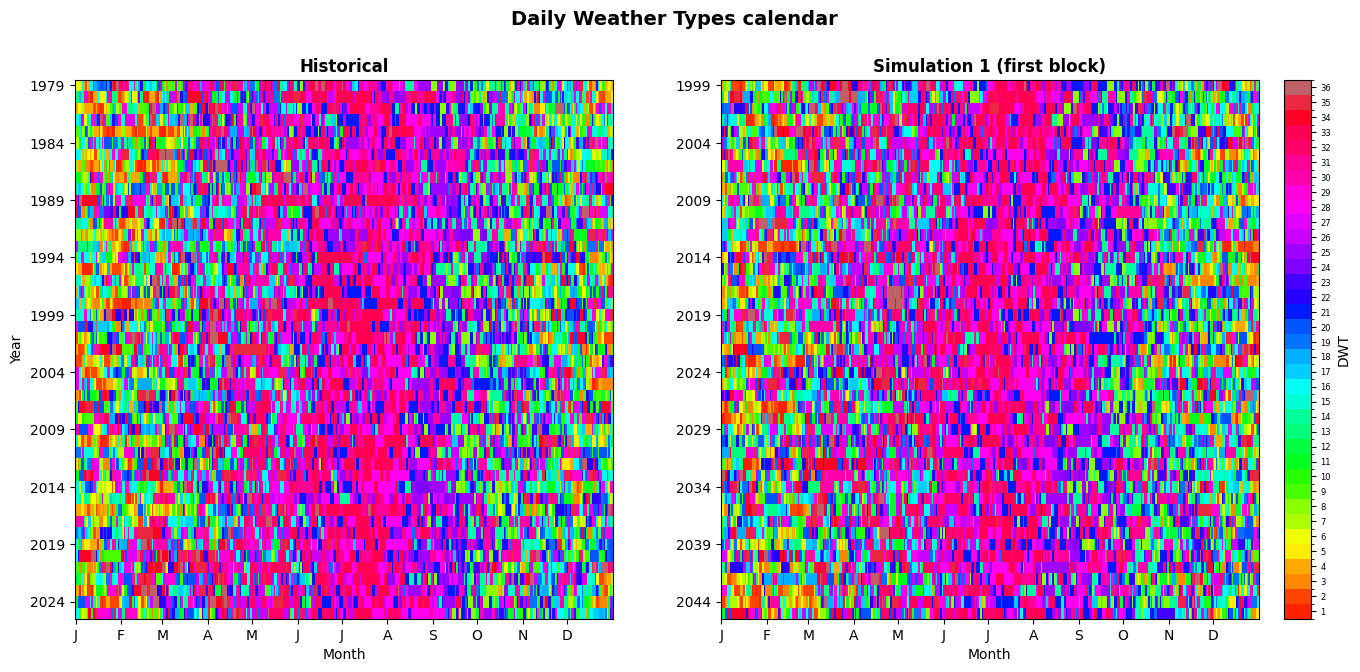

In [13]:
def calendar_matrix(seq, times):
    years_all = np.asarray(times.year)
    years = np.unique(years_all)
    M = np.full((len(years), 366), np.nan)
    M[np.searchsorted(years, years_all), np.asarray(times.dayofyear) - 1] = seq
    return years, M

panels = [
    ("Historical", *calendar_matrix(hist, hist_time)),
    ("Simulation 1 (first block)", *calendar_matrix(sims[0, :n_hist], sim_time[:n_hist])),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (title, years, M) in zip(axes, panels):
    im = ax.imshow(M, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest")
    ax.set_xticks(np.array(month_starts) - 1)
    ax.set_xticklabels(month_names)
    ax.set_yticks(range(0, len(years), 5))
    ax.set_yticklabels(years[::5])
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Month")
axes[0].set_ylabel("Year")

cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, ticks=positions)
cbar.ax.tick_params(labelsize=6)
cbar.set_label("DWT")
fig.suptitle("Daily Weather Types calendar", fontsize=14, fontweight="bold")
plt.show()

### 7.2 Frequency and persistence

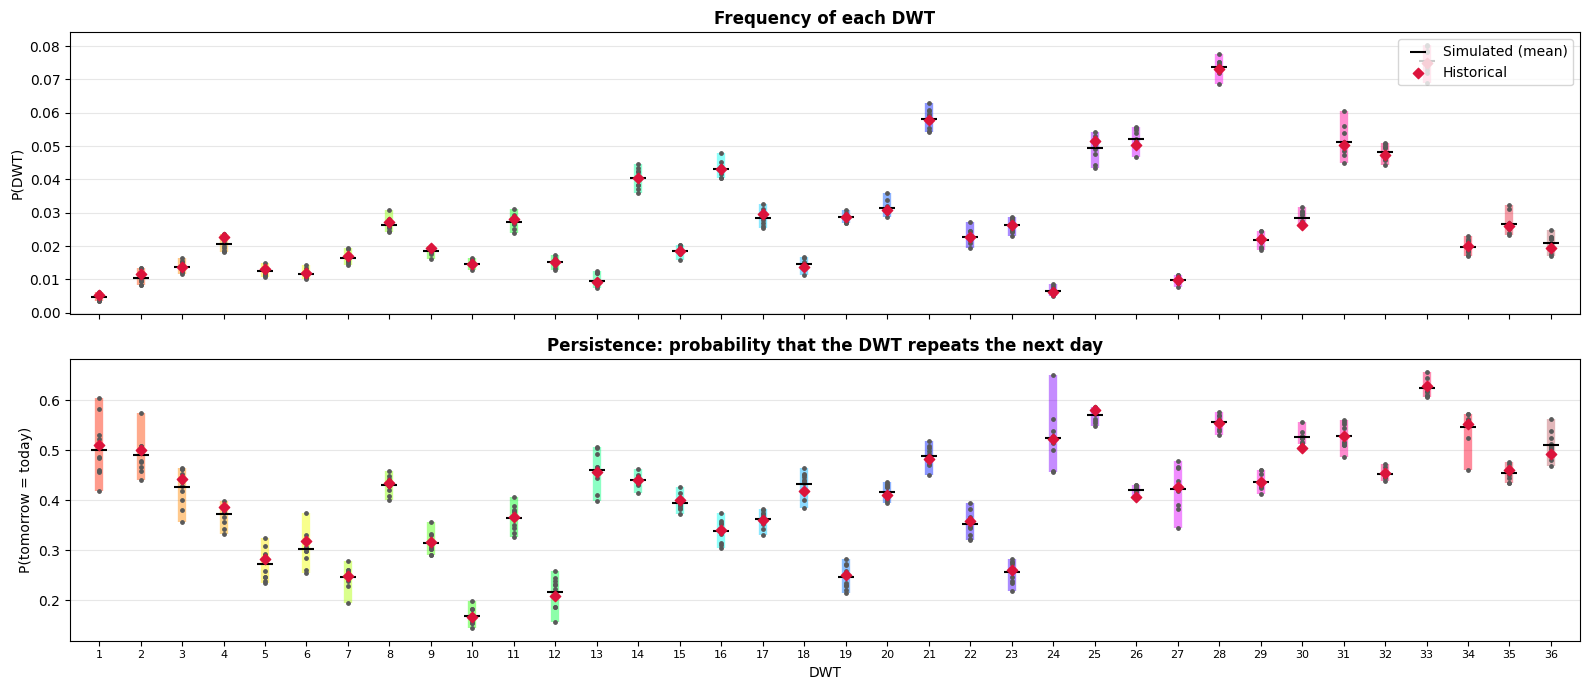

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

range_plot(axes[0], freq_blocks, freq_hist)
axes[0].set_ylabel("P(DWT)")
axes[0].set_title("Frequency of each DWT", fontweight="bold")
axes[0].legend(loc="upper right")

idx = np.arange(K)
range_plot(axes[1], P_blocks[:, idx, idx], np.diag(P_hist))
axes[1].set_ylabel("P(tomorrow = today)")
axes[1].set_title("Persistence: probability that the DWT repeats the next day", fontweight="bold")
axes[1].set_xlabel("DWT")

plt.tight_layout()
plt.show()

### 7.3 Transition flows

Most persistent: DWT 33 | Least persistent: DWT 10


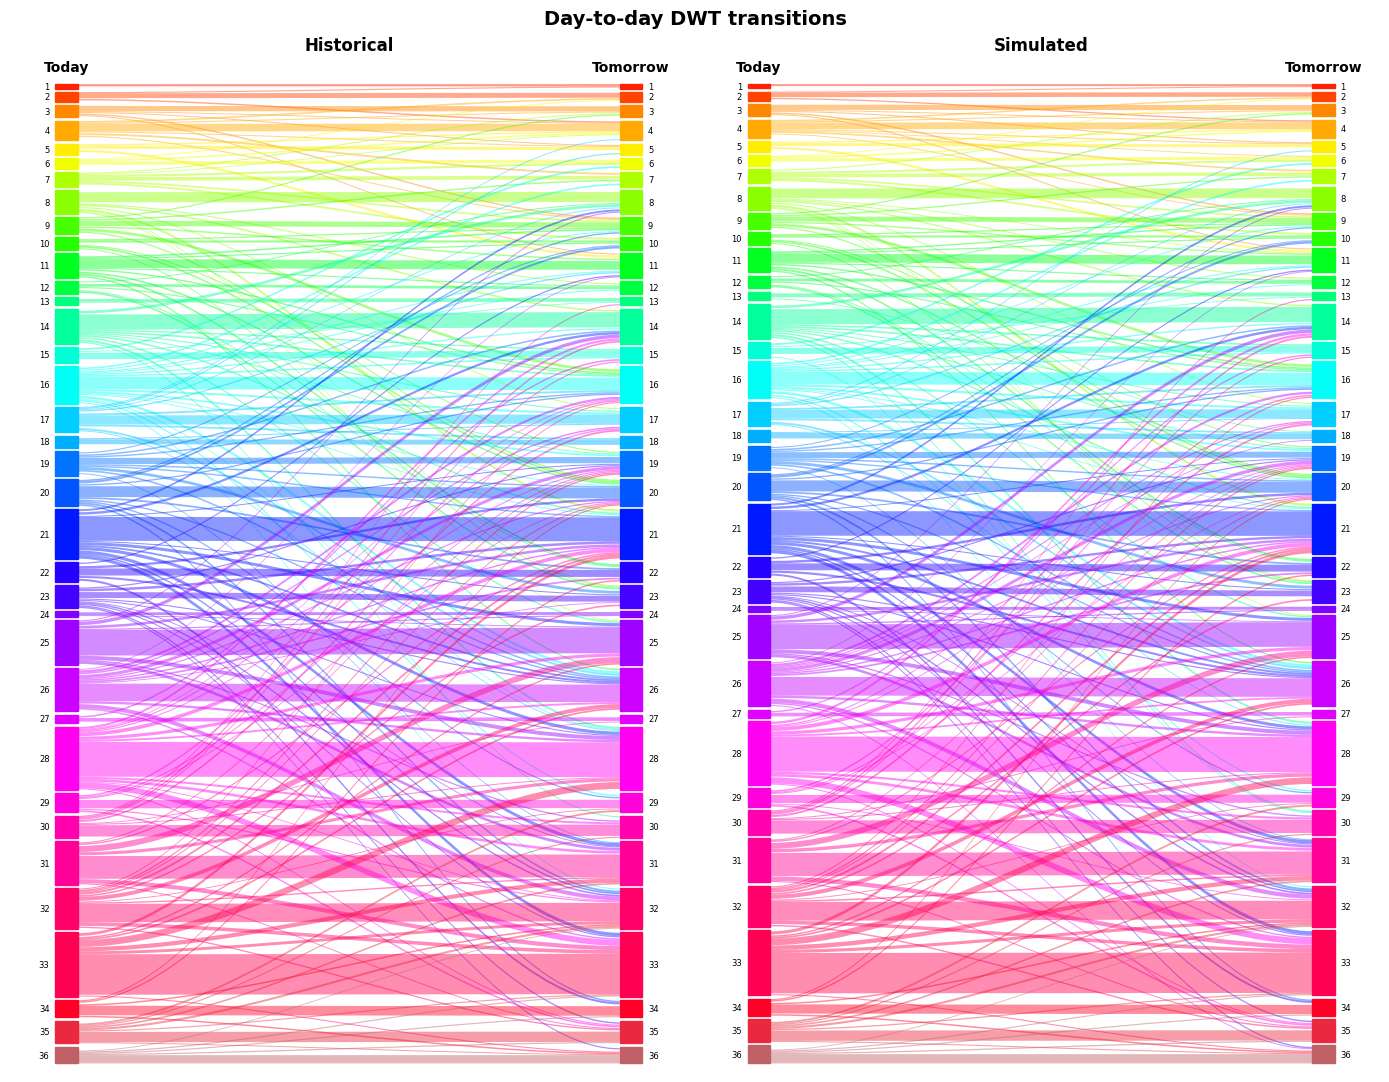

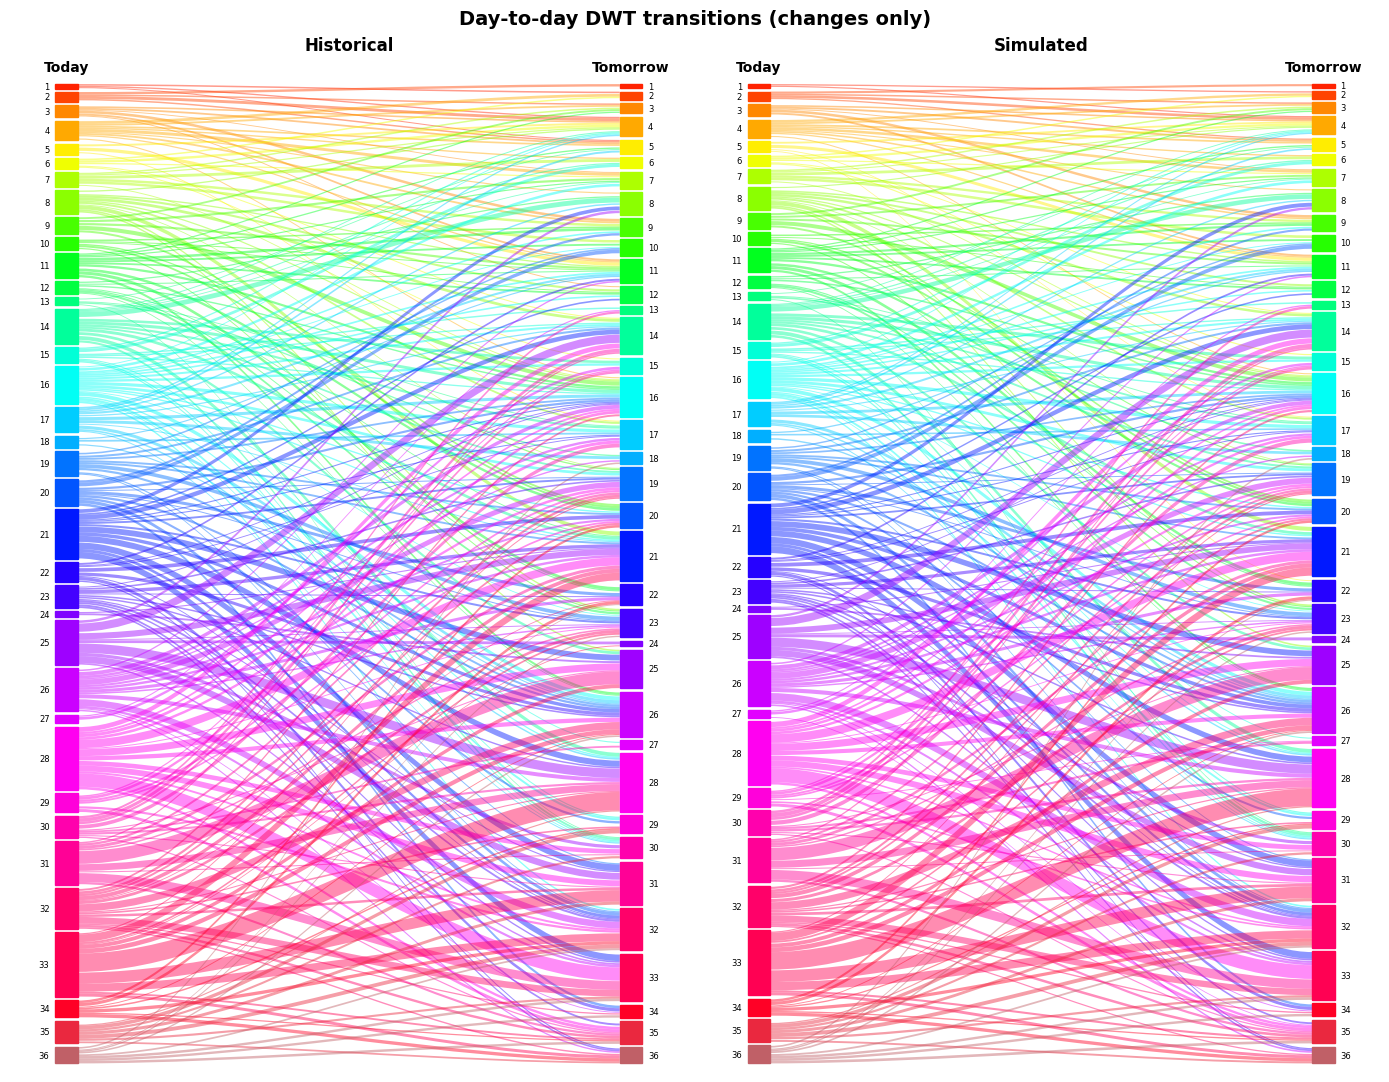

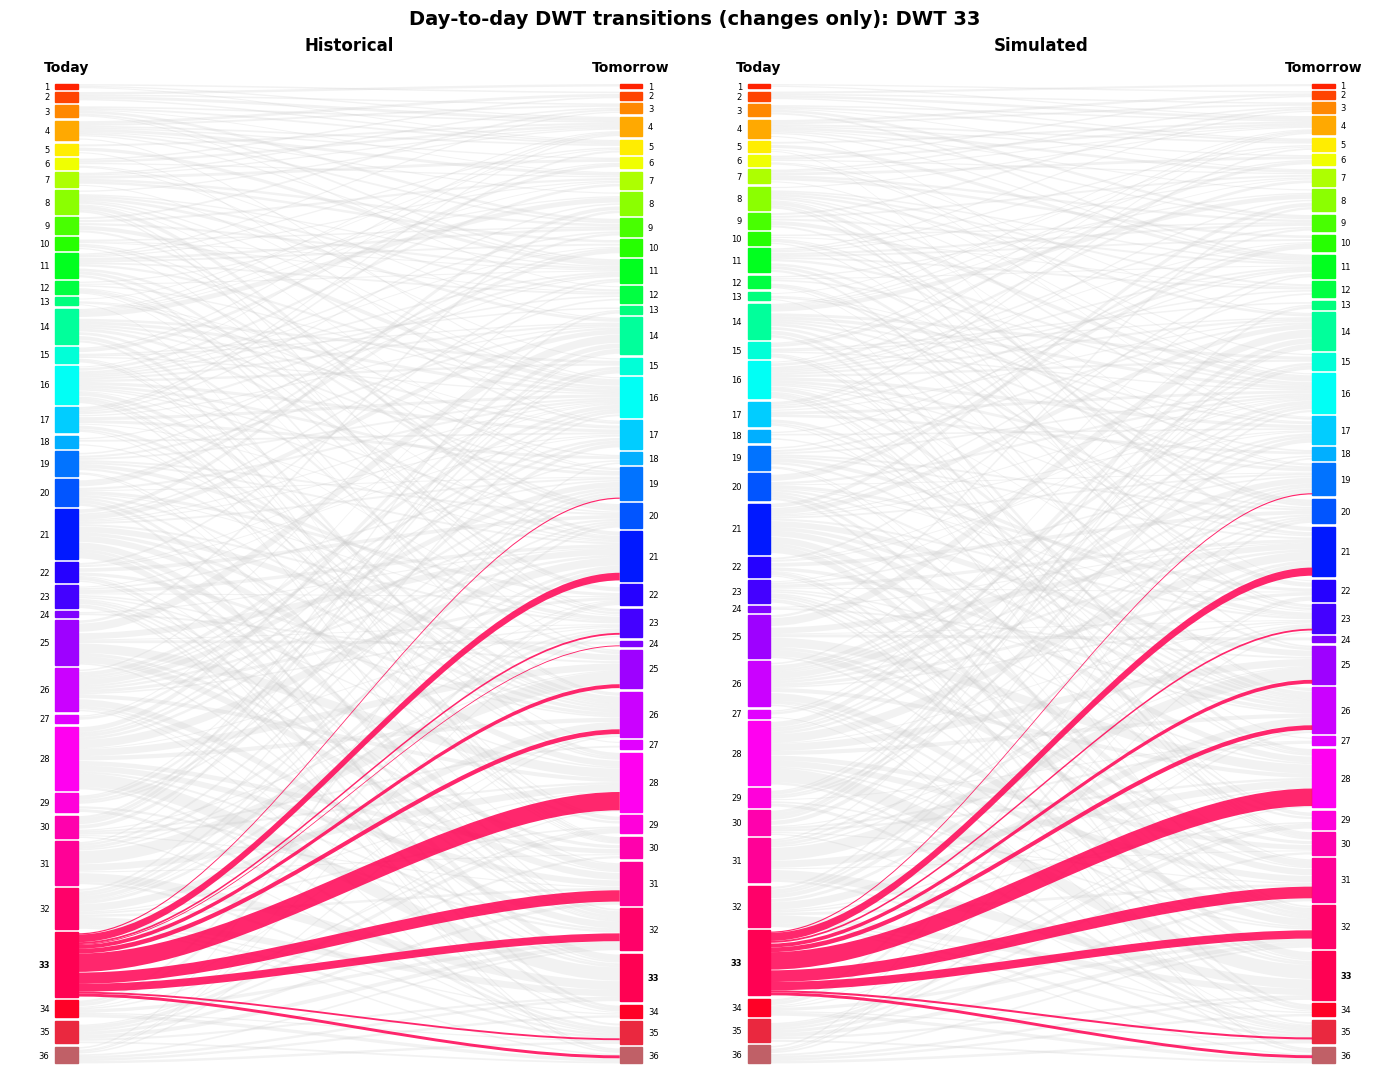

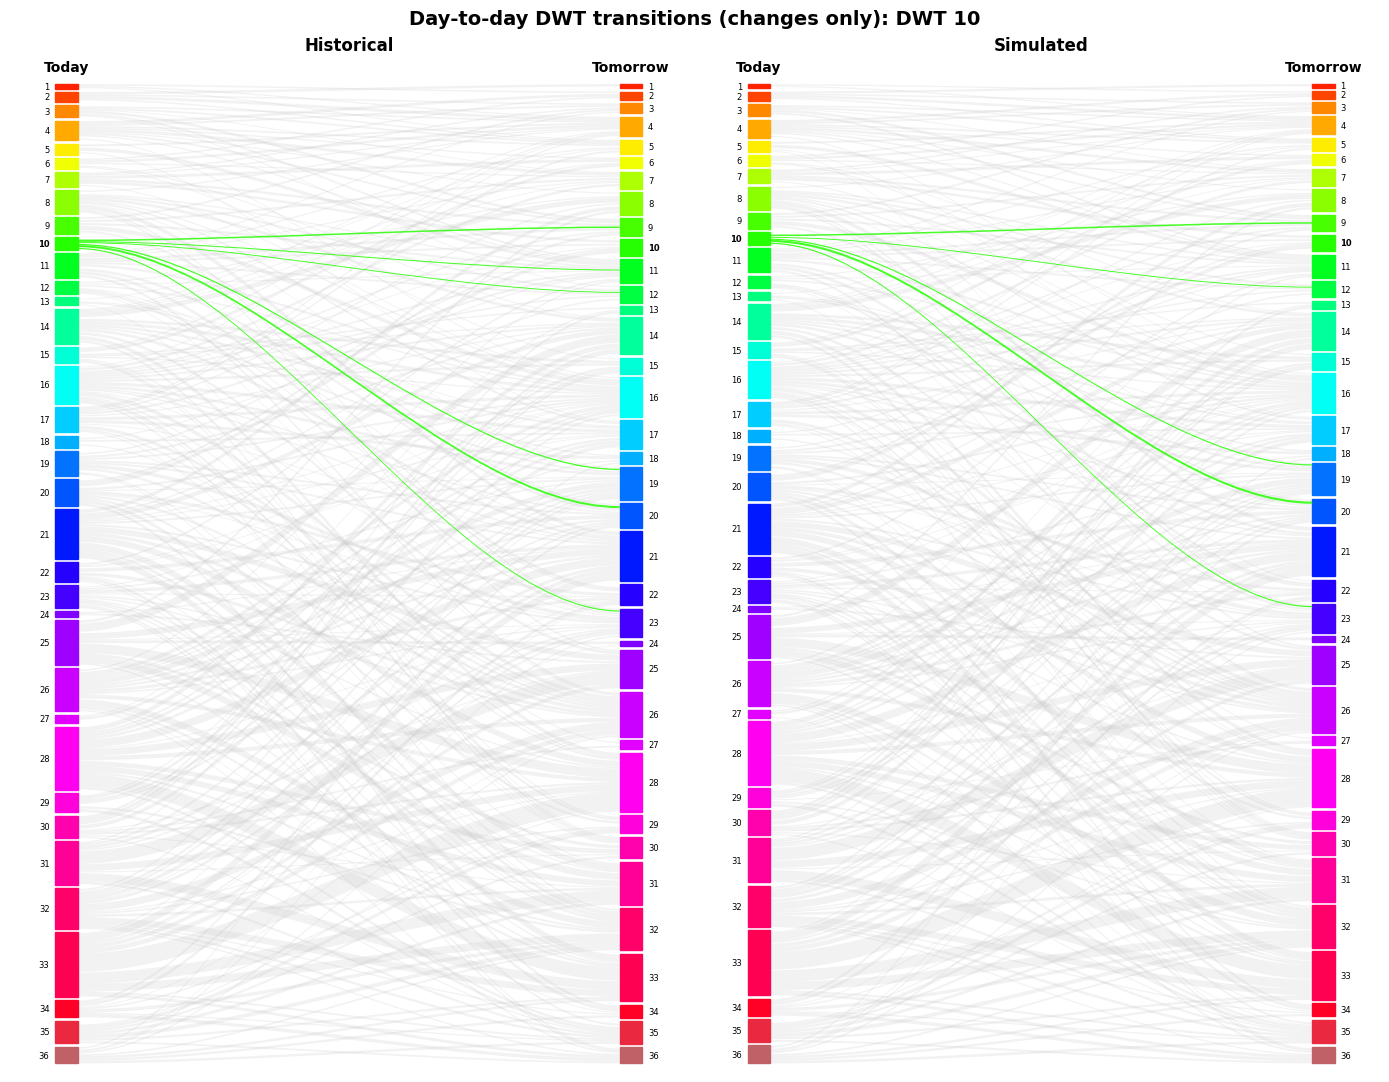

In [15]:
def draw_flow(ax, P, freq, title, highlight=None, min_flow=0.001, gap=0.004):
    """Alluvial diagram of day-to-day transitions.
    Left = DWT today (height = frequency), right = DWT tomorrow.
    Band width = freq_i * P(i -> j). Flows smaller than `min_flow` are hidden.
    If `highlight` is a DWT number, only its flows are colored."""
    x0, x1, w = 0.0, 1.0, 0.04

    def stack(heights):
        tops, y = [], 1.0
        for h in heights:
            tops.append(y)
            y -= h + gap
        return np.array(tops)

    flows = freq[:, None] * P
    left_h, right_h = flows.sum(1), flows.sum(0)
    left_top, right_top = stack(left_h), stack(right_h)
    l_cur, r_cur = left_top.copy(), right_top.copy()

    for i in range(K):
        for j in range(K):
            h = flows[i, j]
            ly0, ry0 = l_cur[i], r_cur[j]
            l_cur[i] -= h
            r_cur[j] -= h
            if h < min_flow:
                continue
            if highlight is None:
                fc, alpha, z = colors[i], 0.45, 1
            elif i == highlight - 1:
                fc, alpha, z = colors[i], 0.85, 3
            else:
                fc, alpha, z = "0.8", 0.25, 1
            ly1, ry1 = ly0 - h, ry0 - h
            xm0, xm1 = x0 + w + 0.3, x1 - 0.3
            verts = [(x0 + w, ly0), (xm0, ly0), (xm1, ry0), (x1, ry0),
                     (x1, ry1), (xm1, ry1), (xm0, ly1), (x0 + w, ly1), (x0 + w, ly0)]
            codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4,
                     Path.LINETO, Path.CURVE4, Path.CURVE4, Path.CURVE4, Path.CLOSEPOLY]
            ax.add_patch(PathPatch(Path(verts, codes), fc=fc, ec="none", alpha=alpha, zorder=z))

    for k in range(K):
        ax.add_patch(plt.Rectangle((x0, left_top[k] - left_h[k]), w, left_h[k], color=colors[k]))
        ax.add_patch(plt.Rectangle((x1, right_top[k] - right_h[k]), w, right_h[k], color=colors[k]))
        bold = "bold" if highlight == k + 1 else "normal"
        ax.text(x0 - 0.01, left_top[k] - left_h[k] / 2, k + 1, ha="right", va="center",
                fontsize=6, fontweight=bold)
        ax.text(x1 + w + 0.01, right_top[k] - right_h[k] / 2, k + 1, ha="left", va="center",
                fontsize=6, fontweight=bold)
    ax.text(x0 + w / 2, 1.015, "Today", ha="center", fontweight="bold")
    ax.text(x1 + w / 2, 1.015, "Tomorrow", ha="center", fontweight="bold")
    ax.set_xlim(-0.08, 1.12)
    ax.set_ylim(right_top[-1] - right_h[-1] - 0.01, 1.03)
    ax.axis("off")
    ax.set_title(title, fontweight="bold")

P_sim_all = to_probs(sum(transition_counts(s) for s in sims))
freq_sim_all = np.bincount(sims.ravel() - 1, minlength=K) / sims.size

def changes_only(P):
    """Remove persistence (diagonal) and renormalize: 'if it changes, where does it go?'"""
    Q = P.copy()
    np.fill_diagonal(Q, 0)
    return to_probs(Q)

def flow_figure(highlight=None, exclude_self=False):
    Ph, Ps = P_hist, P_sim_all
    if exclude_self:
        Ph, Ps = changes_only(Ph), changes_only(Ps)
    fig, axes = plt.subplots(1, 2, figsize=(14, 11))
    draw_flow(axes[0], Ph, freq_hist, "Historical", highlight=highlight)
    draw_flow(axes[1], Ps, freq_sim_all, "Simulated", highlight=highlight)
    title = "Day-to-day DWT transitions"
    if exclude_self:
        title += " (changes only)"
    if highlight is not None:
        title += f": DWT {highlight}"
    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

most_persistent = int(np.argmax(np.diag(P_hist))) + 1
least_persistent = int(np.argmin(np.diag(P_hist))) + 1
print(f"Most persistent: DWT {most_persistent} | Least persistent: DWT {least_persistent}")

flow_figure()                                           # all transitions
flow_figure(exclude_self=True)                          # without persistence
flow_figure(highlight=most_persistent, exclude_self=True)
flow_figure(highlight=least_persistent, exclude_self=True)

### 7.4 Where does a DWT go the next day?

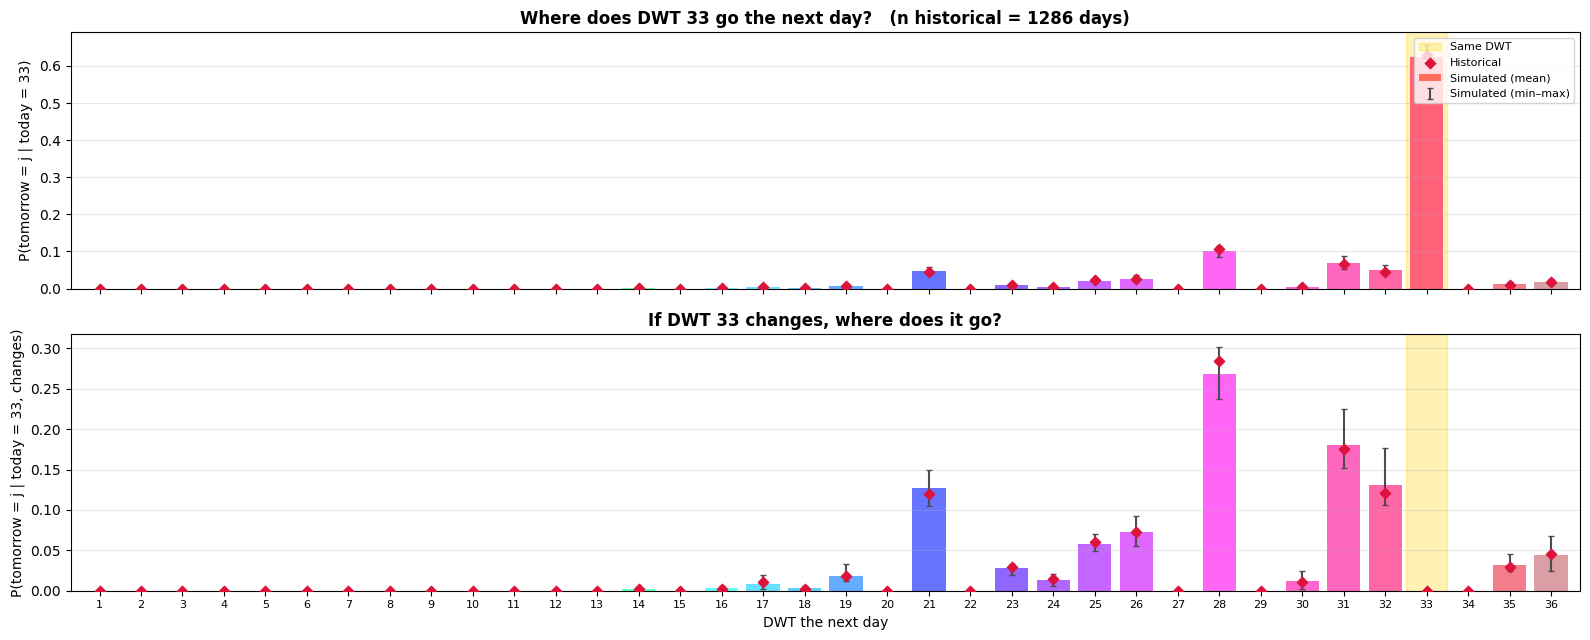

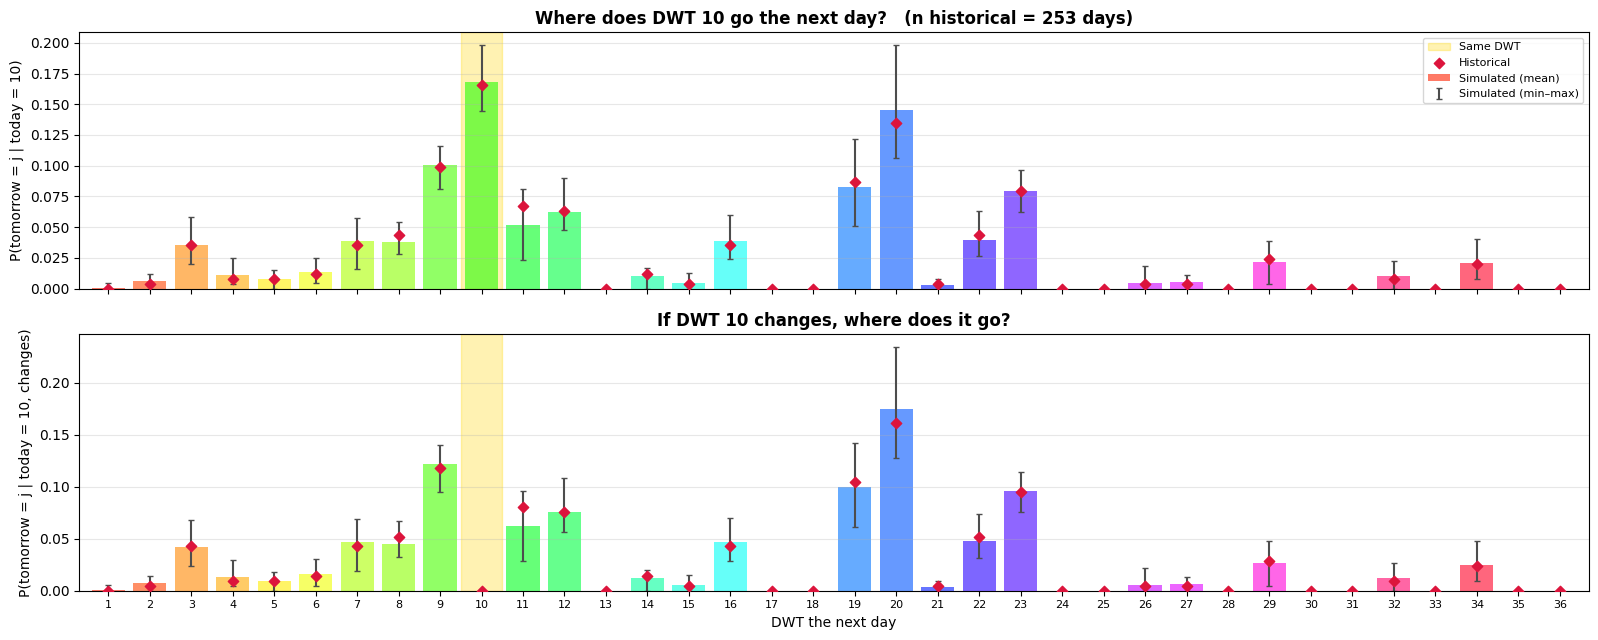

In [16]:
def plot_from_dwt(i):
    k = i - 1
    n_i = int(transition_counts(hist)[k].sum())

    hist_row = P_hist[k]
    sim_rows = P_blocks[:, k, :]

    # "If it changes, where does it go?": same row without the diagonal, renormalized
    def without_self(rows):
        rows = np.array(rows, dtype=float, ndmin=2).copy()
        rows[:, k] = 0
        s = rows.sum(axis=1, keepdims=True)
        return np.divide(rows, s, out=np.zeros_like(rows), where=s > 0)

    hist_change = without_self(hist_row)[0]
    sim_change = without_self(sim_rows)

    fig, axes = plt.subplots(2, 1, figsize=(16, 6.5), sharex=True)
    for ax, h, sr, ylabel, title in [
        (axes[0], hist_row, sim_rows, f"P(tomorrow = j | today = {i})",
         f"Where does DWT {i} go the next day?   (n historical = {n_i} days)"),
        (axes[1], hist_change, sim_change, f"P(tomorrow = j | today = {i}, changes)",
         f"If DWT {i} changes, where does it go?"),
    ]:
        mean, lo, hi = sr.mean(0), sr.min(0), sr.max(0)
        ax.axvspan(i - 0.5, i + 0.5, color="gold", alpha=0.3, label="Same DWT")
        ax.bar(positions, mean, color=colors, alpha=0.6, label="Simulated (mean)")
        ax.errorbar(positions, mean, yerr=[mean - lo, hi - mean], fmt="none", ecolor="0.3",
                    capsize=2, label="Simulated (min–max)")
        ax.scatter(positions, h, marker="D", s=28, color="crimson", zorder=3, label="Historical")
        ax.set_ylabel(ylabel)
        ax.set_title(title, fontweight="bold")
        ax.grid(axis="y", alpha=0.3)
    axes[0].legend(loc="upper right", fontsize=8)
    axes[1].set_xticks(positions)
    axes[1].set_xticklabels(positions, fontsize=8)
    axes[1].set_xlim(0.3, K + 0.7)
    axes[1].set_xlabel("DWT the next day")
    plt.tight_layout()
    plt.show()

plot_from_dwt(most_persistent)
plot_from_dwt(least_persistent)

### 7.5 Spell lengths

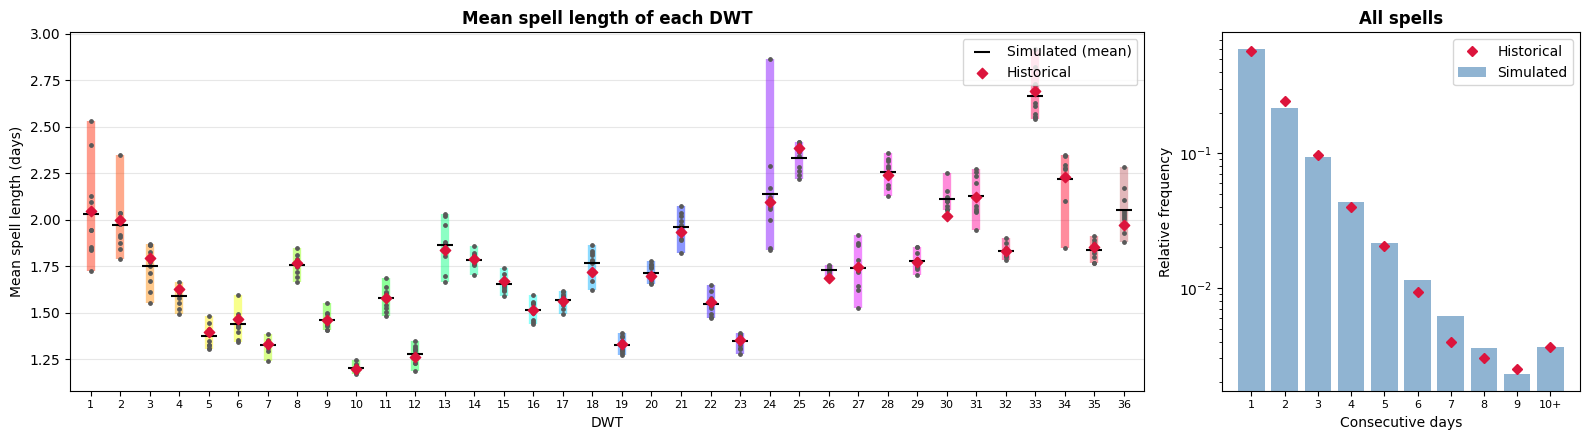

In [17]:
def mean_run_per_dwt(seq):
    dwt, length = run_lengths(seq)
    return np.array([length[dwt == k].mean() if np.any(dwt == k) else np.nan
                     for k in range(1, K + 1)])

mr_hist = mean_run_per_dwt(hist)
mr_blocks = np.array([mean_run_per_dwt(b) for b in blocks])

max_len = 10
bins = np.arange(1, max_len + 2)
_, len_hist = run_lengths(hist)
len_sim = np.concatenate([run_lengths(b)[1] for b in blocks])
h_hist, _ = np.histogram(np.clip(len_hist, 1, max_len), bins=bins, density=True)
h_sim, _ = np.histogram(np.clip(len_sim, 1, max_len), bins=bins, density=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5), gridspec_kw={"width_ratios": [3, 1]})

range_plot(axes[0], mr_blocks, mr_hist)
axes[0].set_xlabel("DWT")
axes[0].set_ylabel("Mean spell length (days)")
axes[0].set_title("Mean spell length of each DWT", fontweight="bold")
axes[0].legend(loc="upper right")

axes[1].bar(bins[:-1], h_sim, color="steelblue", alpha=0.6, label="Simulated")
axes[1].plot(bins[:-1], h_hist, "D", color="crimson", ms=5, label="Historical")
axes[1].set_yscale("log")
axes[1].set_xticks(bins[:-1])
axes[1].set_xticklabels([str(b) for b in bins[:-2]] + [f"{max_len}+"], fontsize=8)
axes[1].set_xlabel("Consecutive days")
axes[1].set_ylabel("Relative frequency")
axes[1].set_title("All spells", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

Most persistent: DWT 33 | Least persistent: DWT 10


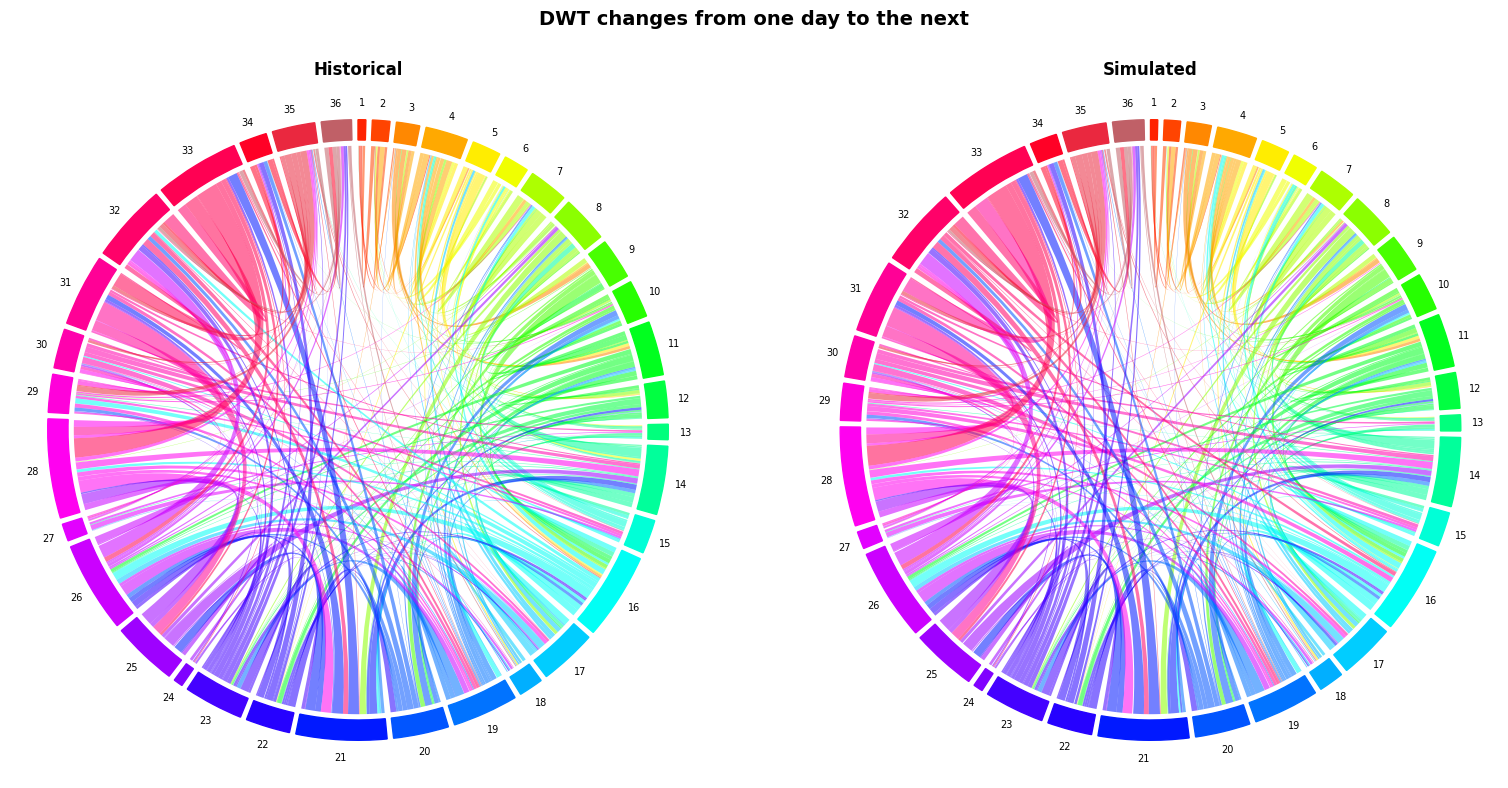

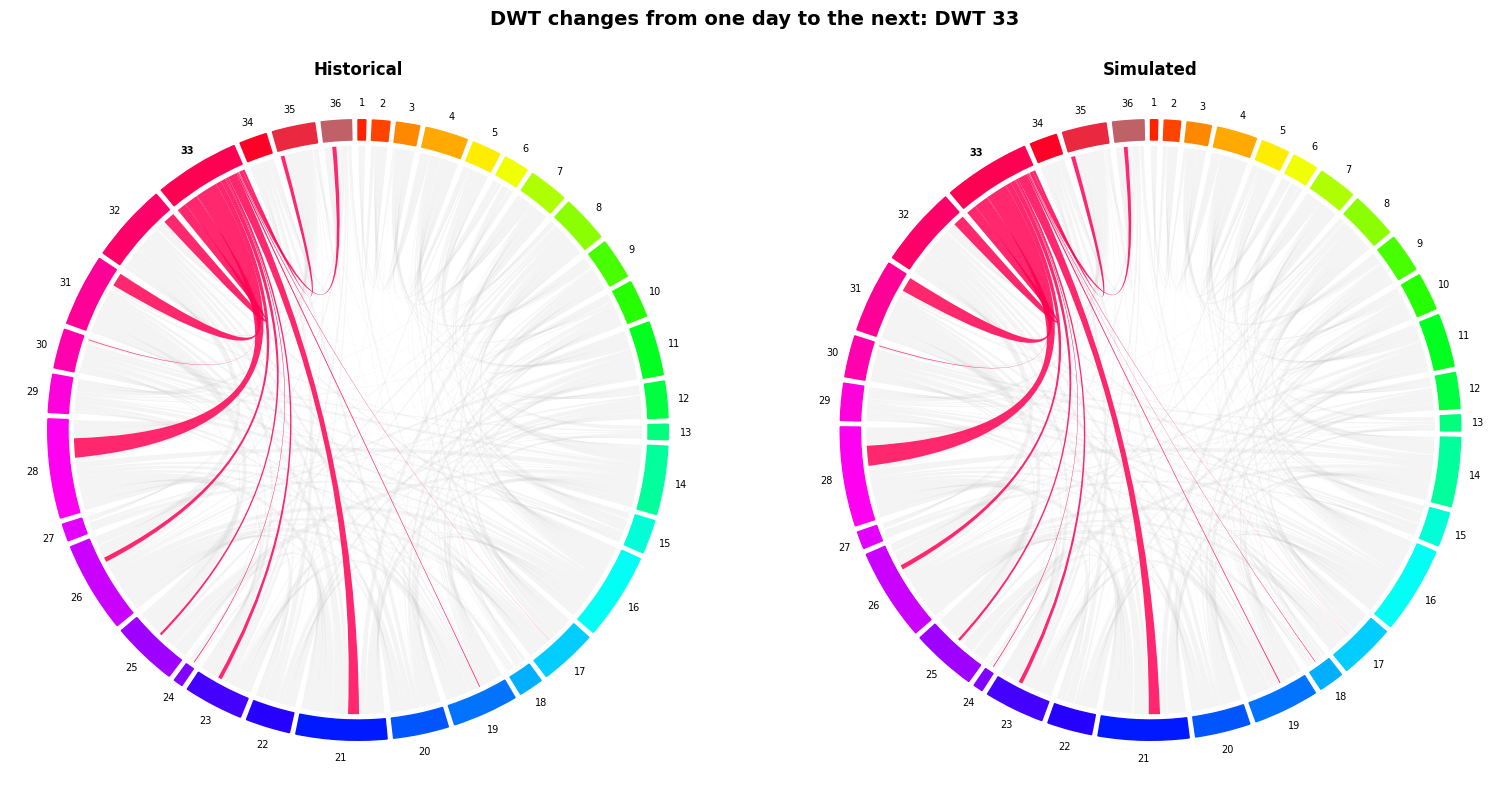

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Wedge

# ---------- Simulated transitions (all simulations pooled) ----------
P_sim_all = to_probs(sum(transition_counts(s) for s in sims))
freq_sim_all = np.bincount(sims.ravel() - 1, minlength=K) / sims.size

most_persistent = int(np.argmax(np.diag(P_hist))) + 1
least_persistent = int(np.argmin(np.diag(P_hist))) + 1
print(f"Most persistent: DWT {most_persistent} | Least persistent: DWT {least_persistent}")


def change_flows(P, freq):
    """Fraction of days with each DWT change (persistence removed)."""
    F = freq[:, None] * P
    np.fill_diagonal(F, 0)
    return F / F.sum()


def draw_chord(ax, F, title, highlight=None, min_flow=0.0005, gap_deg=1.2):
    """Chord diagram of DWT transitions.
    F[i, j] = fraction of days going from DWT i+1 to DWT j+1 (diagonal = 0).
    Arc length = outgoing flow of each DWT. Each ribbon joins a pair (i, j):
    width at arc i = flow i -> j, width at arc j = flow j -> i.
    Ribbons smaller than `min_flow` are hidden."""
    F = F / F.sum()
    gap = np.deg2rad(gap_deg)
    scale = (2 * np.pi - gap * K) / F.sum()

    # Angular segments; inside each arc, destinations ordered so neighbours sit side by side
    seg = np.zeros((K, K, 2))
    arc = np.zeros((K, 2))
    theta = np.pi / 2
    for i in range(K):
        arc[i, 0] = theta
        for d in range(1, K):
            j = (i - d) % K
            seg[i, j] = theta, theta + F[i, j] * scale
            theta += F[i, j] * scale
        arc[i, 1] = theta
        theta += gap

    # Ribbons
    r_in = 0.98
    for i in range(K):
        for j in range(i + 1, K):
            if F[i, j] + F[j, i] < min_flow:
                continue
            a0, a1 = seg[i, j]
            b0, b1 = seg[j, i]
            src = i if F[i, j] >= F[j, i] else j
            if highlight is None:
                fc, alpha, z = colors[src], 0.55, 1
            elif highlight - 1 in (i, j):
                fc, alpha, z = colors[highlight - 1], 0.85, 3
            else:
                fc, alpha, z = "0.8", 0.2, 1

            pa = [(r_in * np.cos(a), r_in * np.sin(a)) for a in np.linspace(a0, a1, 12)]
            pb = [(r_in * np.cos(a), r_in * np.sin(a)) for a in np.linspace(b0, b1, 12)]
            verts = pa + [(0, 0), pb[0]] + pb[1:] + [(0, 0), pa[0]] + [pa[0]]
            codes = ([Path.MOVETO] + [Path.LINETO] * (len(pa) - 1)
                     + [Path.CURVE3, Path.CURVE3]
                     + [Path.LINETO] * (len(pb) - 1)
                     + [Path.CURVE3, Path.CURVE3]
                     + [Path.CLOSEPOLY])
            ax.add_patch(PathPatch(Path(verts, codes), fc=fc, ec="none", alpha=alpha, zorder=z))

    # Outer ring and labels
    for k in range(K):
        t0, t1 = np.rad2deg(arc[k])
        ax.add_patch(Wedge((0, 0), 1.07, t0, t1, width=0.07, color=colors[k], zorder=4))
        mid = np.deg2rad((t0 + t1) / 2)
        weight = "bold" if highlight == k + 1 else "normal"
        ax.text(1.13 * np.cos(mid), 1.13 * np.sin(mid), k + 1,
                ha="center", va="center", fontsize=7, fontweight=weight)

    ax.set_xlim(1.2, -1.2)          # mirrored x-axis: DWTs run clockwise from the top
    ax.set_ylim(-1.2, 1.2)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontweight="bold")


F_hist = change_flows(P_hist, freq_hist)
F_sim = change_flows(P_sim_all, freq_sim_all)


def chord_figure(highlight=None):
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    draw_chord(axes[0], F_hist, "Historical", highlight=highlight)
    draw_chord(axes[1], F_sim, "Simulated", highlight=highlight)
    title = "DWT changes from one day to the next"
    if highlight is not None:
        title += f": DWT {highlight}"
    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


chord_figure()
chord_figure(highlight=most_persistent)

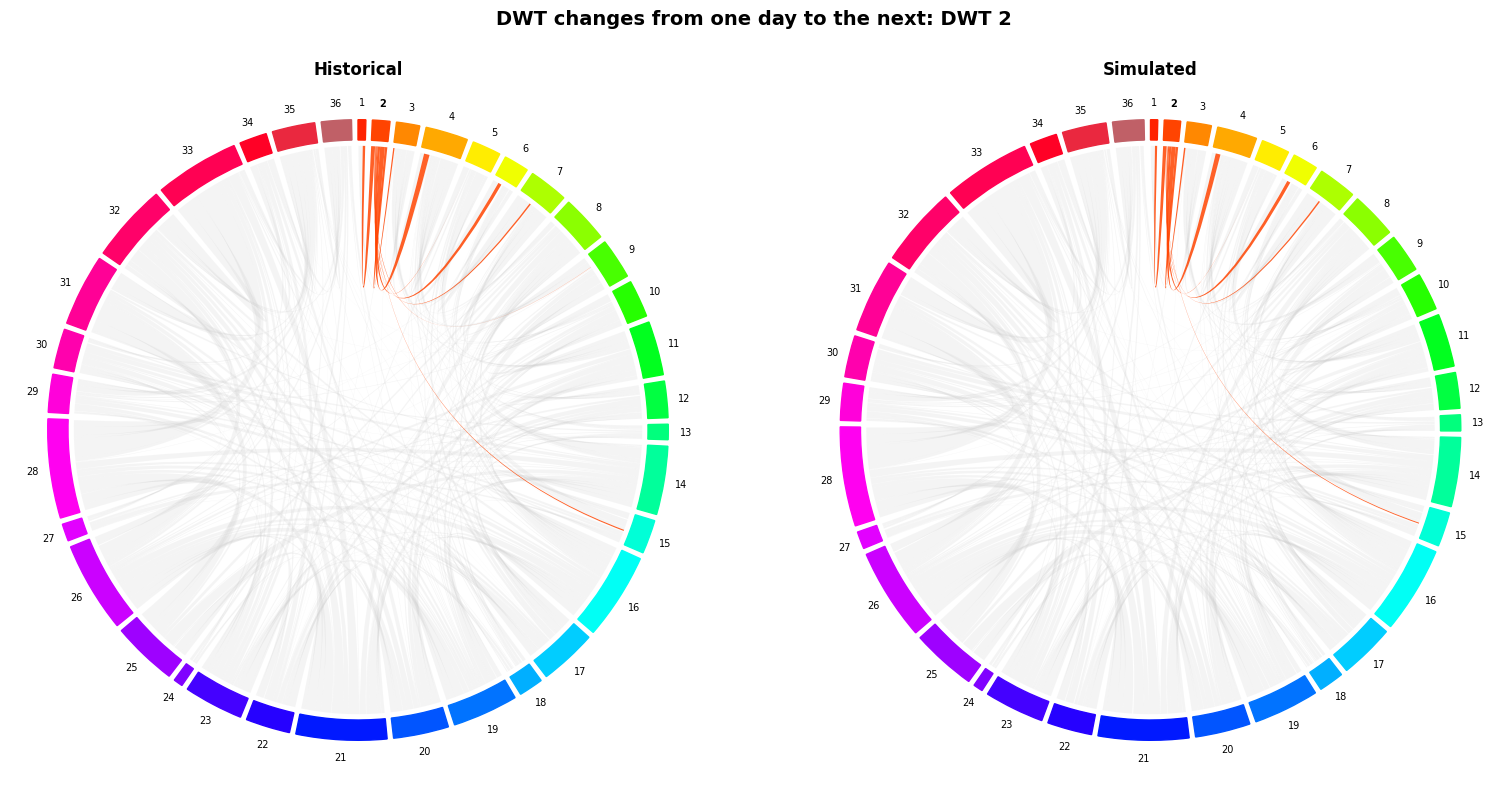

In [19]:
chord_figure(highlight=2)